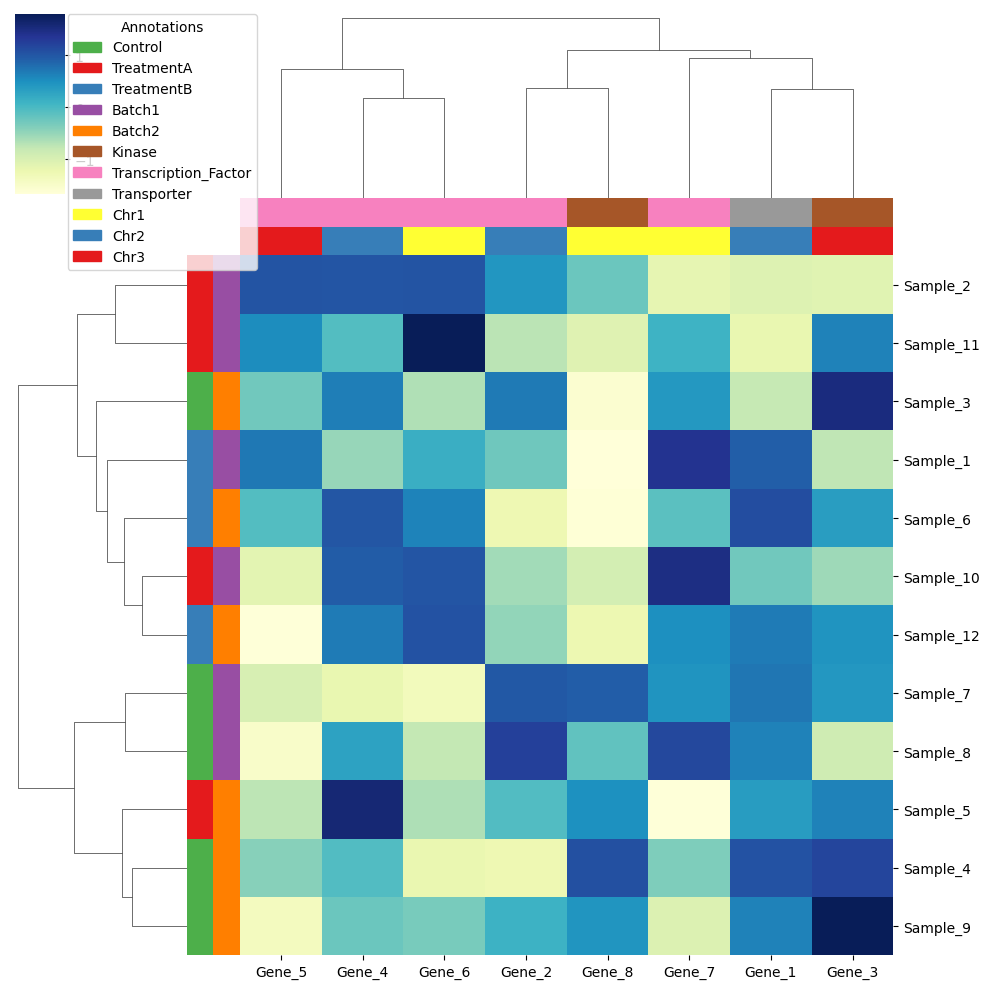

In [3]:
# complex_heatmap.py

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1) Generate random expression data
num_samples = 12
num_genes   = 8
data = np.random.randn(num_samples, num_genes) * 2 + 10
df = pd.DataFrame(
    data, 
    index=[f"Sample_{i+1}" for i in range(num_samples)],
    columns=[f"Gene_{j+1}" for j in range(num_genes)]
)

# 2) Create row annotations: Condition, Batch
conditions = ["Control", "TreatmentA", "TreatmentB"]
batches    = ["Batch1", "Batch2"]

df_row_ann = pd.DataFrame({
    "Condition": np.random.choice(conditions, num_samples),
    "Batch":     np.random.choice(batches, num_samples)
}, index=df.index)

condition_colors = {"Control": "#4daf4a", "TreatmentA": "#e41a1c", "TreatmentB": "#377eb8"}
batch_colors     = {"Batch1": "#984ea3", "Batch2": "#ff7f00"}

row_colors_condition = df_row_ann["Condition"].map(condition_colors)
row_colors_batch     = df_row_ann["Batch"].map(batch_colors)

# 3) Create column annotations: Gene_Family, Chromosome
gene_families = ["Kinase", "Transcription_Factor", "Transporter"]
chromosomes   = ["Chr1", "Chr2", "Chr3"]

df_col_ann = pd.DataFrame({
    "Gene_Family": np.random.choice(gene_families, num_genes),
    "Chromosome":  np.random.choice(chromosomes,   num_genes)
}, index=df.columns)

family_colors = {
    "Kinase":               "#a65628",
    "Transcription_Factor": "#f781bf",
    "Transporter":          "#999999"
}
chrom_colors = {"Chr1": "#ffff33", "Chr2": "#377eb8", "Chr3": "#e41a1c"}

col_colors_family = df_col_ann["Gene_Family"].map(family_colors)
col_colors_chrom  = df_col_ann["Chromosome"].map(chrom_colors)

# 4) Create the clustermap
g = sns.clustermap(
    df,
    row_cluster=True,
    col_cluster=True,
    row_colors=[row_colors_condition, row_colors_batch],
    col_colors=[col_colors_family, col_colors_chrom],
    cmap="YlGnBu",
    method="ward",
    metric="euclidean",
    z_score=0,
    figsize=(10, 10)
)

# 5) Construct a single legend for row/column annotation colors
patches_condition = [mpatches.Patch(color=c, label=l) for l, c in condition_colors.items()]
patches_batch     = [mpatches.Patch(color=c, label=l) for l, c in batch_colors.items()]
patches_family    = [mpatches.Patch(color=c, label=l) for l, c in family_colors.items()]
patches_chrom     = [mpatches.Patch(color=c, label=l) for l, c in chrom_colors.items()]

all_patches = patches_condition + patches_batch + patches_family + patches_chrom
plt.legend(
    handles=all_patches,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0,
    title="Annotations"
)

plt.show()